In [4]:
import Tensor as t
import Operations as o
import numpy as np
import matplotlib.pyplot as plt

A recurrent nerual network (RNN) was designed to deal with inputs of arbitrary size, and outputs of arbitrary size. They work as models $M$ that use a memory sequence to keep track of context.

Given the input sequence as $(x_1,x_2,x_3,..)$ and the output sequence as $(y_1,y_2,y_3,...)$ where $x_j$ and $y_j$ are tensors, 

The idea is to have two ANN's: one that updates the memory, another that takes the memory and outputs the next expected tensor.

Mathematically, this look like this:

$$M_h(x_{j},h_{j-1}) = h_{j}$$

$$M_x(h_j) = y_j$$

Given an error function $E(predicted,actual)$ that measures how different two tensors are*, we can write the general loss function as 

$$Loss = \sum_{j=1}^N E(M_x(h_j),y_j)$$

where $h_1 = 0$ to represent an empty memory.

*The error funciton E formally only needs to be nonnegative for all inputs, 0 only when $predicted = actual$, and should ideally monotically decrease when heading in the direction towards $predicted = actual$

# backprop on RNN's

Conducting gradient descent on a RNN is called backprop through time (BPTT). 

First, we need to realize there are two paramaters: the paramaters of the output model $\theta_x$ and the paramaters of the memory model $\theta_h$

It would serve us best to explicitly write out how these parameters intertwine inside of a particular output $M_x(h_j)$



$$M_x(\theta_x,h_j) = M_x(\theta_x,M_h(\theta_h,h_{j-1}))  =  M_x(\theta_x,M_h(\theta_h,M_h(\theta_h,h_{j-2}))) = ...$$

As we can see, the contributions for $\theta_h$ roll back with time all the way to $j = 1$

The trick is to start at the end.

our current computaitonal graph will automatically calculate the gradients with respect to each input, including $\nabla_{\theta_x} E$ and $\nabla_{h_j} E$.

So, we automatically have the incoming gradient with respect to the paramaters, and an extra memory term.

Now we take advantage of the linearity of gradients. We track $\nabla_{M_h} E$, and append the value $\nabla_{h_j} E$ to it for each iteraction.

So our program looks like this for $j = n$ and going down:
1. calculate $\nabla_{\theta_x} E$ by doing normal backprop.
2. calculate $\nabla_{h_j} E$ again, done by backprop
3. Append $\nabla_{M_h} E += \nabla_{h_j} E$
4. Run backprop on the memory model



Elman simple RNN:

$$h_j = \sigma(x_{j-1}W_h + h_{j-1}U_h + b_h)$$

$$y_j = \sigma(h_jW_x + b_x)$$

We are using row major order, meaning $h_j, y_j, x_{j-1}$ are all row vectors.



In [14]:
INPUT_DIM = 1
HIDDEN_DIM = 10
OUTPUT_DIM = 1

In [ ]:

W_h, U_h, b_h = np.random.uniform(0,1,(INPUT_DIM,HIDDEN_DIM)), np.random.uniform(0,1,(HIDDEN_DIM,HIDDEN_DIM)), np.random.uniform(0,1,(1,HIDDEN_DIM))

W_x, b_x = np.random.uniform(0,1,(HIDDEN_DIM,OUTPUT_DIM)), np.random.uniform(0,1,(1,OUTPUT_DIM))

def train(x_values,y_values, lr=3):
    h_prev = t.TensorNode(np.zeros(shape=(1,HIDDEN_DIM)),False) #is not a paramater, rather fixed when considering this timestamp. Its gradients will be accounted for in a earlier timestamp
    losses = np.empty(len(x_values),dtype=t.TensorNode)
    temp = 0
    for (x_value, y_value) in zip(x_values, y_values):
        x_j = t.TensorNode(x_value,False)
        y_j_true = t.TensorNode(y_value,False)
        h_j = o.sigmoid(x_j @ W_h + h_prev @ U_h  + b_h)
        y_j = o.sigmoid(h_j @ W_x + b_x)
        Loss = o.norm_squared(y_j-y_j_true)
        losses[temp] = Loss
        h_prev = h_j
        temp+=1
    lossContainer = losses[-1].compile()
    for j in losses:
        j.temp_grad = np.ones_like(j.temp_grad)
        j.backprop()

    for level in reversed(lossContainer):
        for node in level:
            node.backprop()
    for level in lossContainer:
        for node in level:
            node.update_params(lr)
    
        







        



LSTM gates:

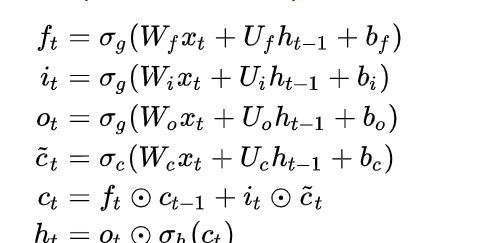

Where  denotes element wise product

You can also be the alpha and combine the three upper equations into one:

$$[f_t,i_t,o_t,c_hat_t] = \sigma_g(x_tW_h + h_{t-1}U_h + b_h)$$

Where $W_if, U_{if} \in R^{4 \times a \times b}$ and $b_{if} \in R^{4 \times b}$ and $x_t \in R^{1 \times a}$

Checking the signatures makes it apparent why we can do this:

$x_tW_{if} \in R^{1 \times a} x R^{4 \times a \times b} = R^{4 \times b}$

This effectively multiplies $x_t$ by each matrix. Same logic goes for $h_{t-1}U_h$

Then we repeat with the rest of the equation lines. 



C:\Users\hi_is\AppData\Local\Temp\ipykernel_31708\673412383.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


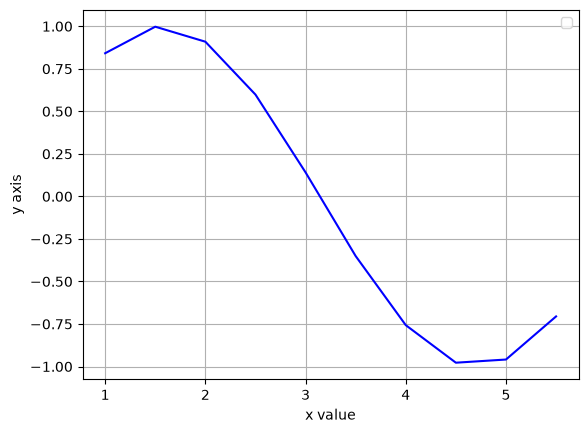

In [10]:
x = np.arange(1,6,step=0.5)
y = np.sin(x)

plt.plot(x,y,color='blue')
plt.xlabel("x value")
plt.ylabel("y axis")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
W_h, U_h = t.TensorNode(np.random.uniform(size=(4,INPUT_DIM,HIDDEN_DIM))),t.TensorNode(np.random.uniform(size=(4,HIDDEN_DIM,HIDDEN_DIM)))
b_h = t.TensorNode(np.random.uniform(size=(4,HIDDEN_DIM)))

W_out, b_out = t.TensorNode(np.random.uniform(size=(HIDDEN_DIM, OUTPUT_DIM))), t.TensorNode(np.random.uniform(size=(1, OUTPUT_DIM)))

In [37]:
x_values = x
y_values = y
totalLoss = 0
h_prev = t.TensorNode(np.zeros(shape=(1,HIDDEN_DIM)),False)
c_prev = t.TensorNode(np.zeros(shape=(1,HIDDEN_DIM)),False)
for (x_value, y_value) in zip(x_values,y_values):
    x_value = np.array([[[x_value]]])
    y_value = np.array([[[y_value]]])
    total = t.TensorNode(x_value,False) @ W_h + h_prev @ U_h + b_h
    f_t, i_t = o.sigmoid(total.get_index(0)), o.sigmoid(total.get_index(1))
    o_t, c_hat_t = o.sigmoid(total.get_index(2)), o.tanh(total.get_index(3))
    c_t = f_t * c_prev + i_t * c_hat_t
    h_t = o_t * c_t

    lossinomial = o.norm_squared(t.TensorNode(y_value,False) - (h_t @ W_out + b_out))    

    if(totalLoss == 0):
        totalLoss = lossinomial
    else:
        totalLoss += lossinomial
        
    h_prev = h_t
    c_prev = c_t

lossContainer = totalLoss.compile()

print(totalLoss.data)

11979.141388255399


In [36]:
#training
totalLoss.temp_grad = np.ones_like(totalLoss.temp_grad)
for level in reversed(lossContainer):
    for node in level:
        node.backprop()

W_h.data -= 3 * W_h.gradient
W_h.update_gradient_init()
U_h.data -= 3 * U_h.gradient
U_h.update_gradient_init()
b_h.data -= 3 * b_h.gradient
b_h.update_gradient_init()

W_out.data -= 3*W_out.gradient
W_out.update_gradient_init()


for level in lossContainer:
    for node in level:
        node.refresh()

print(totalLoss.data)

11979.141388255399
